In [1]:
# CELL 1: IMPORTING & LOADING DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_score,
                             recall_score, f1_score)

# SMOTE 
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  

# Loading Kaggle Credit Card Fraud Dataset
df = pd.read_csv('creditcard.csv')

print("Dataset Loaded!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud Rate: {df['Class'].mean()*100:.4f}%")
df.head()

Dataset Loaded!
Shape: 284807 rows × 31 columns

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# CELL 2: EXPLORING THE DATA

print("=== DATASET INFO ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
print(df.describe().round(2))

print("\n=== CLASS DISTRIBUTION ===")
counts = df['Class'].value_counts()
print(f"Legitimate (0): {counts[0]} ({counts[0]/len(df)*100:.2f}%)")
print(f"Fraudulent  (1): {counts[1]} ({counts[1]/len(df)*100:.2f}%)")
print(f"\nImbalance Ratio: {counts[0]//counts[1]}:1")

=== DATASET INFO ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== MISSING VALUES ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int6

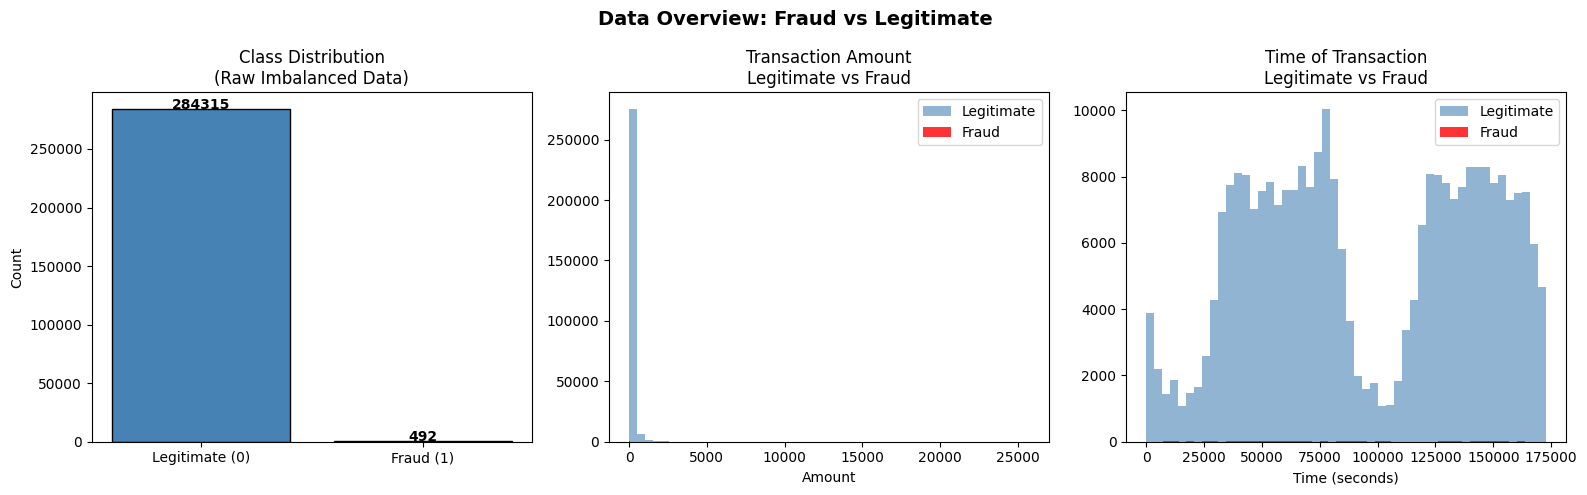

  KEY INSIGHT: Fraud is extremely rare — a model predicting
   'Legitimate' every time would get high accuracy but catch ZERO fraud!


In [3]:
# CELL 3: VISUALIZING CLASS IMBALANCE

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Class distribution bar chart
counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'],
            counts.values,
            color=['steelblue', 'red'],
            edgecolor='black')
axes[0].set_title("Class Distribution\n(Raw Imbalanced Data)")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Plot 2: Transaction Amount - Fraud vs Legitimate
axes[1].hist(df[df['Class']==0]['Amount'],
             bins=50, alpha=0.6, color='steelblue', label='Legitimate')
axes[1].hist(df[df['Class']==1]['Amount'],
             bins=50, alpha=0.8, color='red', label='Fraud')
axes[1].set_title("Transaction Amount\nLegitimate vs Fraud")
axes[1].set_xlabel("Amount")
axes[1].legend()

# Plot 3: Time of transaction
axes[2].hist(df[df['Class']==0]['Time'],
             bins=50, alpha=0.6, color='steelblue', label='Legitimate')
axes[2].hist(df[df['Class']==1]['Time'],
             bins=50, alpha=0.8, color='red', label='Fraud')
axes[2].set_title("Time of Transaction\nLegitimate vs Fraud")
axes[2].set_xlabel("Time (seconds)")
axes[2].legend()

plt.suptitle("Data Overview: Fraud vs Legitimate", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("  KEY INSIGHT: Fraud is extremely rare — a model predicting")
print("   'Legitimate' every time would get high accuracy but catch ZERO fraud!")

In [4]:
# CELL 4: PREPARING FEATURES (X) AND TARGET (y)

X = df.drop(columns=['Class'])   # Time, V1-V28, Amount
y = df['Class']                  # 0 = legitimate, 1 = fraud

print("Features (X):", list(X.columns))
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features (X): ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

X shape: (284807, 30)
y shape: (284807,)

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [5]:
# CELL 5: TRAINING/TESTING SPLITING - MUST HAPPEN BEFORE SMOTE!

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       
    random_state=42,
    stratify=y           
)

print(f"Training set:   {X_train.shape[0]} rows")
print(f"Test set:       {X_test.shape[0]} rows")
print(f"\nTraining fraud cases: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test fraud cases:     {y_test.sum()} ({y_test.mean()*100:.2f}%)")
print("\n Split done! SMOTE will only be applied inside the pipeline on training data.")

Training set:   227845 rows
Test set:       56962 rows

Training fraud cases: 394 (0.17%)
Test fraud cases:     98 (0.17%)

 Split done! SMOTE will only be applied inside the pipeline on training data.


In [6]:
# CELL 6: BUILDING LOGISTIC REGRESSION PIPELINE

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),          
    ('smote',  SMOTE(random_state=42)),    
    ('classifier', LogisticRegression(    
        random_state=42,
        max_iter=1000
    ))
])

# Training the pipeline
lr_pipeline.fit(X_train, y_train)

# Predicting on TEST set 
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1] 

print("Logistic Regression Pipeline trained!")
print(f"\nQuick Results:")
print(f"  Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lr):.3f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_lr):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.3f}")

Logistic Regression Pipeline trained!

Quick Results:
  Precision: 0.058
  Recall:    0.918
  F1-Score:  0.109
  ROC-AUC:   0.971


In [7]:
# CELL 7: BUILDING RANDOM FOREST PIPELINE

rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),              
    ('classifier', RandomForestClassifier(          
        n_estimators=100,
        random_state=42,
        n_jobs=-1        
    ))
])

# Training the pipeline
rf_pipeline.fit(X_train, y_train)

# Predicting on TEST set
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print(" Random Forest Pipeline trained!")
print(f"\nQuick Results:")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_rf):.3f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_rf):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.3f}")

 Random Forest Pipeline trained!

Quick Results:
  Precision: 0.835
  Recall:    0.827
  F1-Score:  0.831
  ROC-AUC:   0.964


In [8]:
# CELL 8: HYPERPARAMETER TUNING WITH GRIDSEARCHCV

# Tuning Logistic Regression 
print(" Tuning Logistic Regression...")

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1.0],
}

lr_grid = GridSearchCV(
    lr_pipeline,
    param_grid=lr_param_grid,
    cv=StratifiedKFold(n_splits=3),   
    scoring='recall',
    n_jobs=1,                          
    verbose=1
)

lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test)
y_prob_lr_tuned = best_lr.predict_proba(X_test)[:, 1]

print(f" Best LR Parameters: {lr_grid.best_params_}")

# Tuning Random Forest 
print("\n Tuning Random Forest... (may take 3-5 minutes)")

rf_param_grid = {
    'classifier__n_estimators': [50],    
    'classifier__max_depth':    [10, 20], 
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=StratifiedKFold(n_splits=3),   
    scoring='recall',
    n_jobs=1,                          
    verbose=1
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print(f" Best RF Parameters: {rf_grid.best_params_}")
print("\n Tuning Complete!")

 Tuning Logistic Regression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
 Best LR Parameters: {'classifier__C': 0.01}

 Tuning Random Forest... (may take 3-5 minutes)
Fitting 3 folds for each of 2 candidates, totalling 6 fits
 Best RF Parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 50}

 Tuning Complete!


In [9]:
# CELL 9: EVALUATING BOTH MODELS

print("=" * 60)
print(" MODEL EVALUATION REPORT")
print("=" * 60)

print("\n--- LOGISTIC REGRESSION (Tuned) ---")
print(classification_report(y_test, y_pred_lr_tuned,
                             target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr_tuned):.4f}")

print("\n--- RANDOM FOREST (Tuned) ---")
print(classification_report(y_test, y_pred_rf_tuned,
                             target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf_tuned):.4f}")

# Summary table
print("\n--- SUMMARY COMPARISON ---")
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [
        precision_score(y_test, y_pred_lr_tuned),
        precision_score(y_test, y_pred_rf_tuned)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr_tuned),
        recall_score(y_test, y_pred_rf_tuned)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr_tuned),
        f1_score(y_test, y_pred_rf_tuned)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr_tuned),
        roc_auc_score(y_test, y_prob_rf_tuned)
    ]
}).round(4)

print(summary.to_string(index=False))

 MODEL EVALUATION REPORT

--- LOGISTIC REGRESSION (Tuned) ---
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score: 0.9715

--- RANDOM FOREST (Tuned) ---
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.51      0.89      0.65        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9853

--- SUMMARY COMPARISON ---
              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.0585  0.9184    0.1100   0.9715
      Random Forest     0.5148  0.8878    0.6517   0.9853


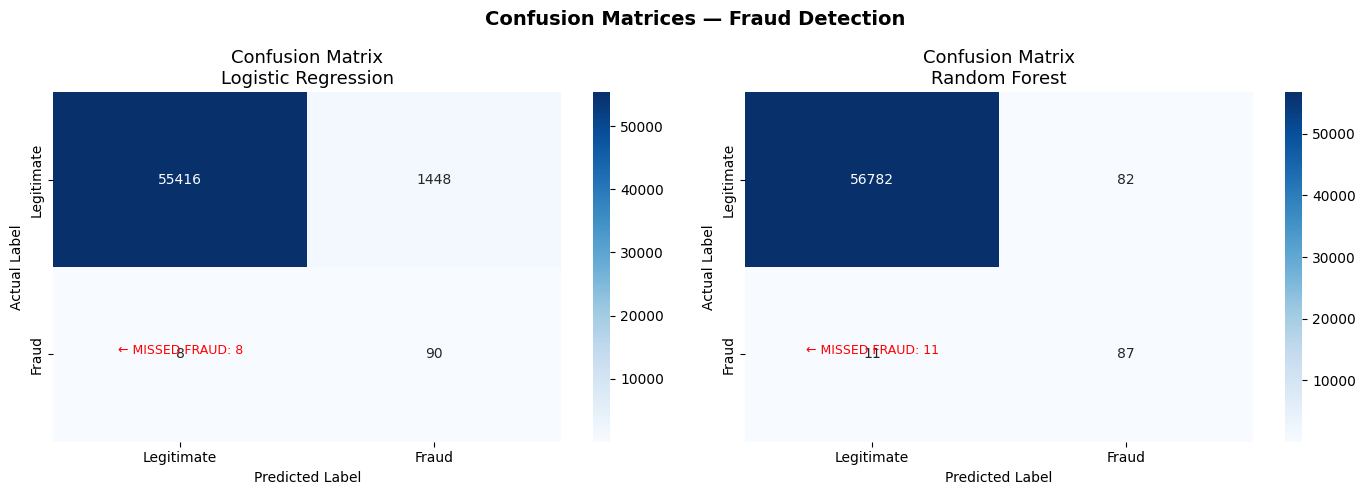

 KEY: Bottom-left cell (FN) = Fraud we MISSED = financial loss!
        We want this number as LOW as possible (high Recall).


In [10]:
# CELL 10: CONFUSION MATRIX VISUALIZATION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = {
    'Logistic Regression': y_pred_lr_tuned,
    'Random Forest':       y_pred_rf_tuned
}

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=13)
    ax.set_ylabel('Actual Label')
    ax.set_xlabel('Predicted Label')

    # Annotating the dangerous cell 
    fn = cm[1][0]
    ax.text(0.5, 1.5, f'← MISSED FRAUD: {fn}',
            ha='center', color='red', fontsize=9)

plt.suptitle("Confusion Matrices — Fraud Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" KEY: Bottom-left cell (FN) = Fraud we MISSED = financial loss!")
print("        We want this number as LOW as possible (high Recall).")

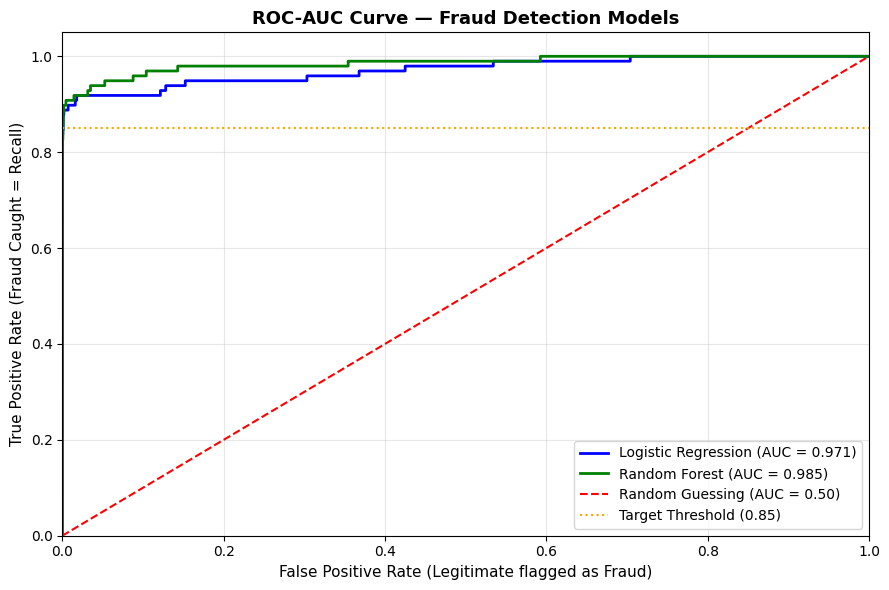

 Logistic Regression AUC: 0.971
 Random Forest AUC:       0.985

 Target AUC > 0.85: PASSED 


In [11]:
# CELL 11: ROC-AUC CURVE

plt.figure(figsize=(9, 6))

# Plotting LR ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr_tuned)
auc_lr = roc_auc_score(y_test, y_prob_lr_tuned)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')

# Plotting RF ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_tuned)
auc_rf = roc_auc_score(y_test, y_prob_rf_tuned)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2,
         label=f'Random Forest (AUC = {auc_rf:.3f})')

# Diagonal line = random guessing baseline
plt.plot([0, 1], [0, 1], color='red', linestyle='--',
         lw=1.5, label='Random Guessing (AUC = 0.50)')

# Target line
plt.axhline(y=0.85, color='orange', linestyle=':', lw=1.5,
            label='Target Threshold (0.85)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Legitimate flagged as Fraud)', fontsize=11)
plt.ylabel('True Positive Rate (Fraud Caught = Recall)', fontsize=11)
plt.title('ROC-AUC Curve — Fraud Detection Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f" Logistic Regression AUC: {auc_lr:.3f}")
print(f" Random Forest AUC:       {auc_rf:.3f}")
print(f"\n Target AUC > 0.85:", "PASSED " if max(auc_lr, auc_rf) > 0.85 else "Need improvement")

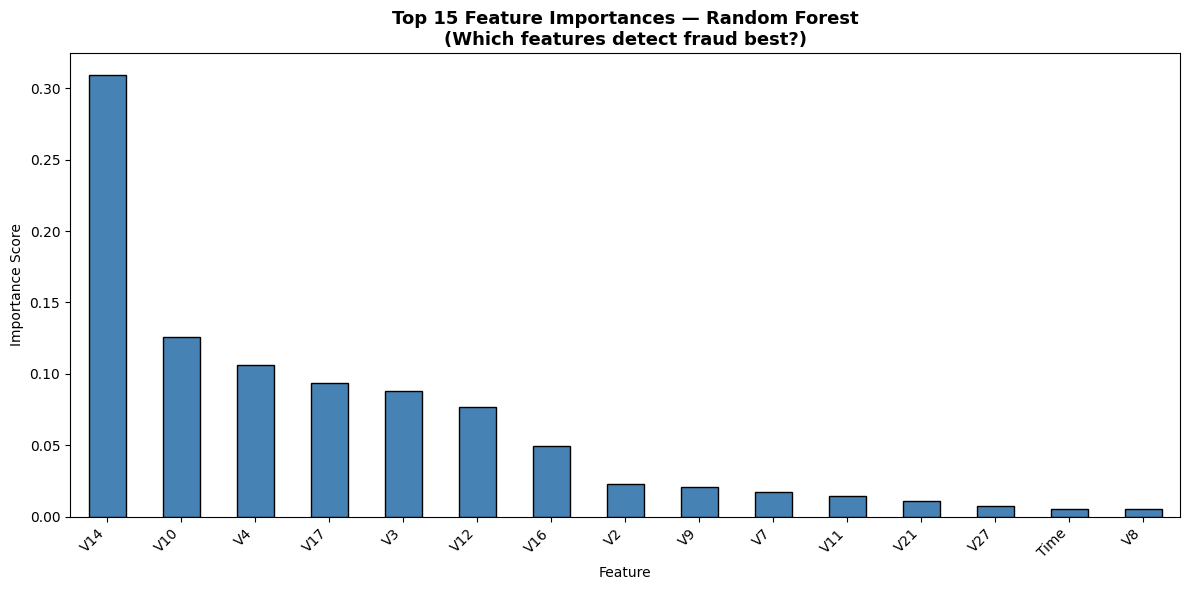

 TOP 3 FRAUD INDICATORS:
   V14: 0.3090
   V10: 0.1257
   V4: 0.1059


In [12]:
# CELL 12: FEATURE IMPORTANCE (Random Forest)

rf_model = best_rf.named_steps['classifier']
feature_names = X.columns
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Showing only TOP 15 features (since we have 30 columns)
plt.figure(figsize=(12, 6))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances — Random Forest\n(Which features detect fraud best?)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(" TOP 3 FRAUD INDICATORS:")
for feat, imp in feat_imp.head(3).items():
    print(f"   {feat}: {imp:.4f}")

In [13]:
# CELL 13: FINAL COMPARISON & CONCLUSION

print("=" * 65)
print(" FINAL PROJECT SUMMARY - FRAUD DETECTION PIPELINE")
print("=" * 65)

print("\n WHAT WE DID:")
print("  1. Loaded highly imbalanced fraud dataset")
print("  2. Performed EDA - found extreme class imbalance")
print("  3. Split data FIRST (stratified 80/20)")
print("  4. Applied SMOTE INSIDE pipeline (zero data leakage)")
print("  5. Trained Logistic Regression + Random Forest")
print("  6. Tuned hyperparameters with GridSearchCV")
print("  7. Evaluated using Precision, Recall, F1, ROC-AUC")

print("\n FINAL METRICS:")
print(f"  Logistic Regression → Recall: {recall_score(y_test, y_pred_lr_tuned):.3f} | ROC-AUC: {roc_auc_score(y_test, y_prob_lr_tuned):.3f}")
print(f"  Random Forest       → Recall: {recall_score(y_test, y_pred_rf_tuned):.3f} | ROC-AUC: {roc_auc_score(y_test, y_prob_rf_tuned):.3f}")

# Picking winner
if roc_auc_score(y_test, y_prob_rf_tuned) >= roc_auc_score(y_test, y_prob_lr_tuned):
    winner = "Random Forest"
else:
    winner = "Logistic Regression"

print(f"\n BEST MODEL: {winner}")
print("\n WHY WE IGNORED ACCURACY:")
print("  A model predicting 'Legitimate' every time = high accuracy")
print("  but ZERO fraud caught = catastrophic financial loss.")
print("  Recall = fraction of actual fraud cases we caught.")
print("  This is the metric that actually protects businesses.")

print("\n PROJECT 2 COMPLETE!")

 FINAL PROJECT SUMMARY - FRAUD DETECTION PIPELINE

 WHAT WE DID:
  1. Loaded highly imbalanced fraud dataset
  2. Performed EDA - found extreme class imbalance
  3. Split data FIRST (stratified 80/20)
  4. Applied SMOTE INSIDE pipeline (zero data leakage)
  5. Trained Logistic Regression + Random Forest
  6. Tuned hyperparameters with GridSearchCV
  7. Evaluated using Precision, Recall, F1, ROC-AUC

 FINAL METRICS:
  Logistic Regression → Recall: 0.918 | ROC-AUC: 0.971
  Random Forest       → Recall: 0.888 | ROC-AUC: 0.985

 BEST MODEL: Random Forest

 WHY WE IGNORED ACCURACY:
  A model predicting 'Legitimate' every time = high accuracy
  but ZERO fraud caught = catastrophic financial loss.
  Recall = fraction of actual fraud cases we caught.
  This is the metric that actually protects businesses.

 PROJECT 2 COMPLETE!
